# Stock Market Price Forecasting Using Time Series Analysis

## Capstone Project

### Problem Statement

The objective of this project is to forecast future stock prices using historical stock market data. Time series forecasting techniques are applied to identify historical trends, analyze seasonality, and predict future stock prices.

The project compares different forecasting approaches and evaluates their performance using standard time series evaluation metrics.

### Tools Used

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Statsmodels
- Prophet
- Scikit-learn

### Dataset

Apple Inc. (AAPL) Historical Stock Prices

In [25]:
# ============================================================
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [26]:
# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv("apple_5yr_one.csv")

df.head()

,Date,Close,High,Low,Open,Volume
0,NaN,AAPL,AAPL,AAPL,AAPL,AAPL
1,2020-06-04,78.32931518554688,79.1312690763083,77.95506657558614,78.83236263047952,87560400
2,2020-06-05,80.56021881103516,80.62097312386399,78.55046881252456,78.57962969607472,137250400
3,2020-06-08,81.03653717041016,81.07056314819836,79.54441498185327,80.25645380649277,95654400
4,2020-06-09,83.59550476074219,83.98919153470604,80.68416273702039,80.71575616737768,147712400


In [27]:
# ============================================================
# Remove Extra Header Row
# ============================================================

df = df.iloc[1:].reset_index(drop=True)

df.head()

,Date,Close,High,Low,Open,Volume
0,2020-06-04,78.32931518554688,79.1312690763083,77.95506657558614,78.83236263047952,87560400
1,2020-06-05,80.56021881103516,80.62097312386399,78.55046881252456,78.57962969607472,137250400
2,2020-06-08,81.03653717041016,81.07056314819836,79.54441498185327,80.25645380649277,95654400
3,2020-06-09,83.59550476074219,83.98919153470604,80.68416273702039,80.71575616737768,147712400
4,2020-06-10,85.74620819091797,86.21522971767824,84.1058417038533,84.54570234634012,166651600


In [28]:
# ============================================================
# Convert Columns to Proper Data Types
# ============================================================

df["Date"] = pd.to_datetime(df["Date"])

numeric_columns = ["Open", "High", "Low", "Close", "Volume"]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1255 non-null   datetime64[ns]
 1   Close   1255 non-null   float64       
 2   High    1255 non-null   float64       
 3   Low     1255 non-null   float64       
 4   Open    1255 non-null   float64       
 5   Volume  1255 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 59.0 KB


In [29]:
# ============================================================
# Basic Dataset Information
# ============================================================

print("Shape :", df.shape)

print("\n")

display(df.head())

print("\n")

display(df.tail())

print("\nMissing Values")

display(df.isnull().sum())

Shape : (1255, 6)




,Date,Close,High,Low,Open,Volume
0,2020-06-04,78.329315,79.131269,77.955067,78.832363,87560400
1,2020-06-05,80.560219,80.620973,78.550469,78.579630,137250400
2,2020-06-08,81.036537,81.070563,79.544415,80.256454,95654400
3,2020-06-09,83.595505,83.989192,80.684163,80.715756,147712400
4,2020-06-10,85.746208,86.215230,84.105842,84.545702,166651600


,Date,Close,High,Low,Open,Volume
1250,2025-05-27,200.210007,200.740005,197.429993,198.300003,56288500
1251,2025-05-28,200.419998,202.729996,199.899994,200.589996,45339700
1252,2025-05-29,199.949997,203.809998,198.509995,203.580002,51396800
1253,2025-05-30,200.850006,201.960007,196.779999,199.369995,70819900
1254,2025-06-02,201.699997,202.130005,200.119995,200.279999,35343100



Missing Values


,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [30]:
# ============================================================
# Set Date as Index
# ============================================================

df.set_index("Date", inplace=True)

df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2020-06-04,78.329315,79.131269,77.955067,78.832363,87560400
2020-06-05,80.560219,80.620973,78.550469,78.579630,137250400
2020-06-08,81.036537,81.070563,79.544415,80.256454,95654400
2020-06-09,83.595505,83.989192,80.684163,80.715756,147712400
2020-06-10,85.746208,86.215230,84.105842,84.545702,166651600


# Exploratory Time Series Analysis

In this section, the historical stock price data is explored to identify long-term trends, price fluctuations, trading volume patterns, and potential characteristics that influence future stock price forecasting.

In [31]:
# ============================================================
# Statistical Summary
# ============================================================

display(df.describe())

,Close,High,Low,Open,Volume
count,1255.000000,1255.000000,1255.000000,1255.000000,1.255000e+03
mean,164.321062,166.006163,162.443943,164.160646,8.078038e+07
std,38.179689,38.364282,37.891117,38.094942,4.191317e+07
min,78.329315,79.131269,77.955067,78.579630,2.323470e+07
25%,136.922234,139.392588,134.935222,136.720468,5.239195e+07
50%,162.264175,163.728834,160.141728,161.654384,7.046270e+07
75%,188.222137,189.675969,186.846649,188.102500,9.563880e+07
max,258.396667,259.474086,257.010028,257.568678,3.743368e+08


In [32]:
# ============================================================
# Missing Values
# ============================================================

print(df.isnull().sum())

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


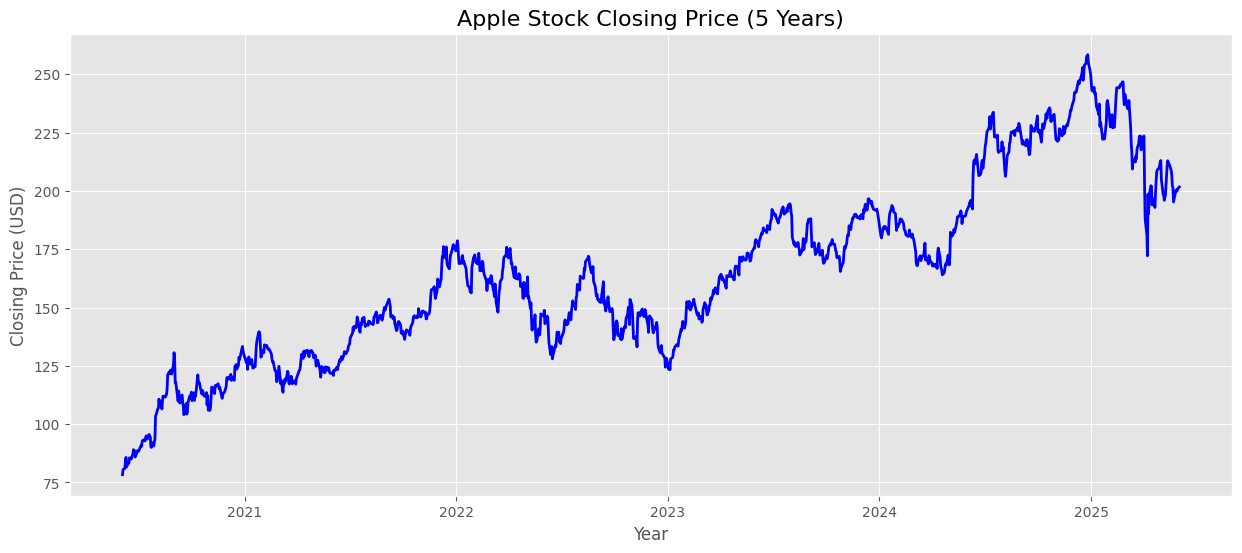

In [33]:
# ============================================================
# Closing Price Over Time
# ============================================================

plt.figure(figsize=(15,6))

plt.plot(
    df.index,
    df["Close"],
    color="blue",
    linewidth=2
)

plt.title("Apple Stock Closing Price (5 Years)", fontsize=16)

plt.xlabel("Year")

plt.ylabel("Closing Price (USD)")

plt.grid(True)

plt.show()

### Business Insight

The closing price exhibits a clear upward trend over the five-year period with noticeable fluctuations. Such behaviour suggests that the stock is non-stationary and requires further analysis before forecasting models like ARIMA can be applied.

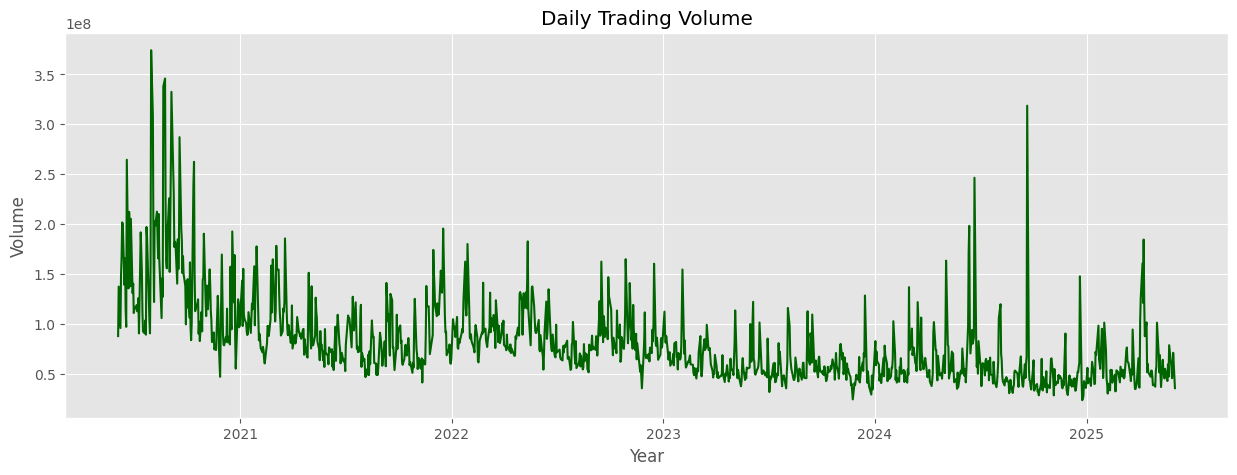

In [34]:
# ============================================================
# Trading Volume
# ============================================================

plt.figure(figsize=(15,5))

plt.plot(
    df.index,
    df["Volume"],
    color="darkgreen"
)

plt.title("Daily Trading Volume")

plt.xlabel("Year")

plt.ylabel("Volume")

plt.grid(True)

plt.show()

### Business Insight

Trading volume varies significantly across the observed period. Large spikes often indicate important market events, earnings announcements, or increased investor activity.

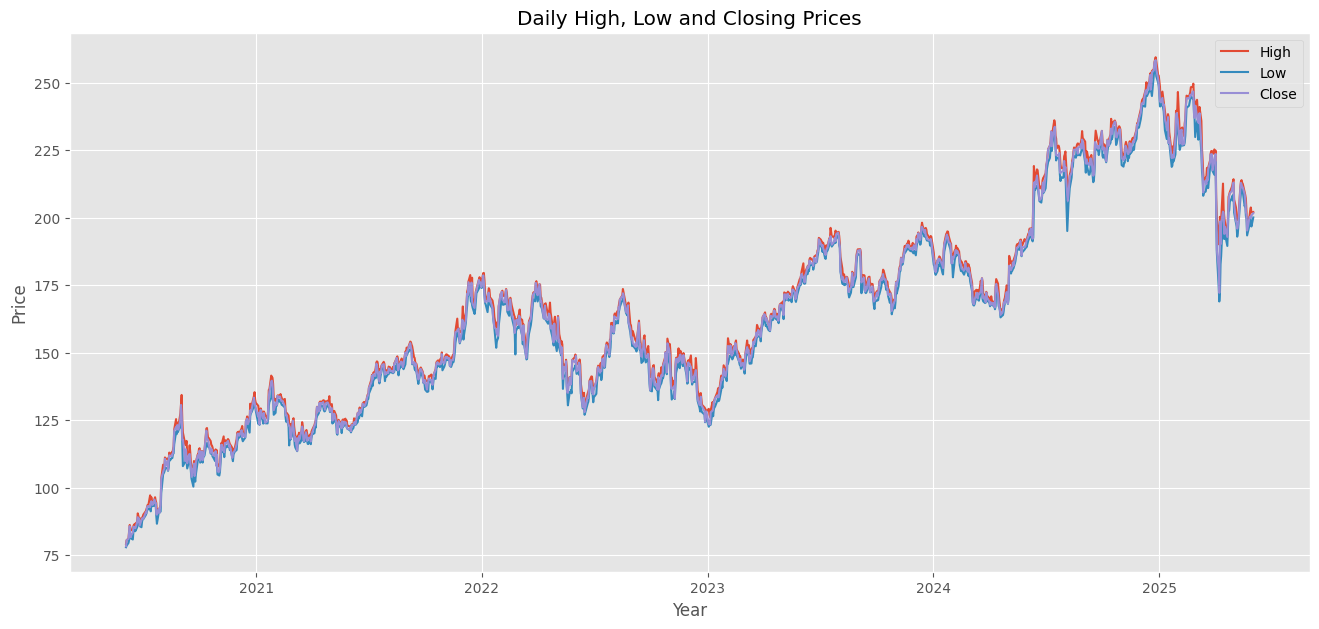

In [35]:
# ============================================================
# High Low Close Prices
# ============================================================

plt.figure(figsize=(16,7))

plt.plot(df.index, df["High"], label="High")

plt.plot(df.index, df["Low"], label="Low")

plt.plot(df.index, df["Close"], label="Close")

plt.title("Daily High, Low and Closing Prices")

plt.xlabel("Year")

plt.ylabel("Price")

plt.legend()

plt.show()

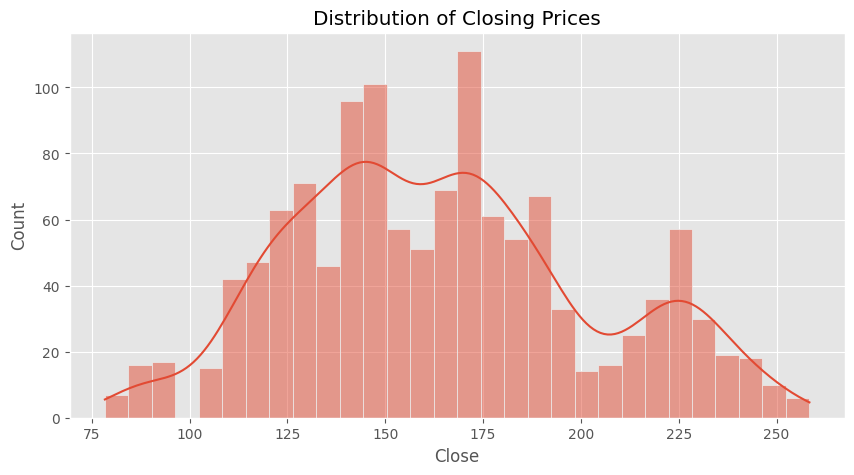

In [36]:
# ============================================================
# Distribution of Closing Prices
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df["Close"],
    bins=30,
    kde=True
)

plt.title("Distribution of Closing Prices")

plt.show()

### Business Insight

The distribution is not perfectly symmetric, indicating changing stock price levels over time. This behaviour is common in financial time series.

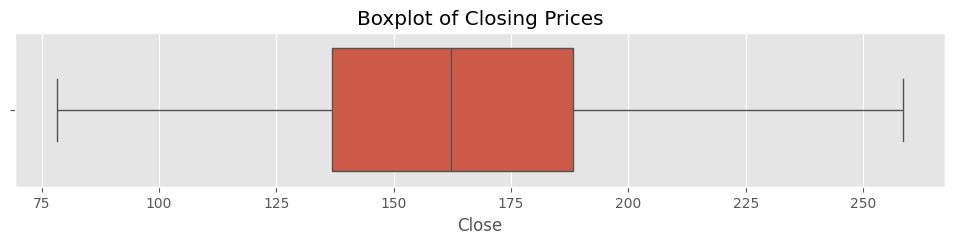

In [37]:
# ============================================================
# Boxplot of Closing Prices
# ============================================================

plt.figure(figsize=(12,2))

sns.boxplot(
    x=df["Close"]
)

plt.title("Boxplot of Closing Prices")

plt.show()

### Business Insight

Several observations appear as outliers. In financial markets these are generally not errors but represent periods of unusually high or low stock prices.

In [38]:
# ============================================================
# Daily Returns
# ============================================================

df["Daily_Return"] = df["Close"].pct_change()

df.head()

,Close,High,Low,Open,Volume,Daily_Return
Date,,,,,,
2020-06-04,78.329315,79.131269,77.955067,78.832363,87560400,NaN
2020-06-05,80.560219,80.620973,78.550469,78.579630,137250400,0.028481
2020-06-08,81.036537,81.070563,79.544415,80.256454,95654400,0.005913
2020-06-09,83.595505,83.989192,80.684163,80.715756,147712400,0.031578
2020-06-10,85.746208,86.215230,84.105842,84.545702,166651600,0.025728


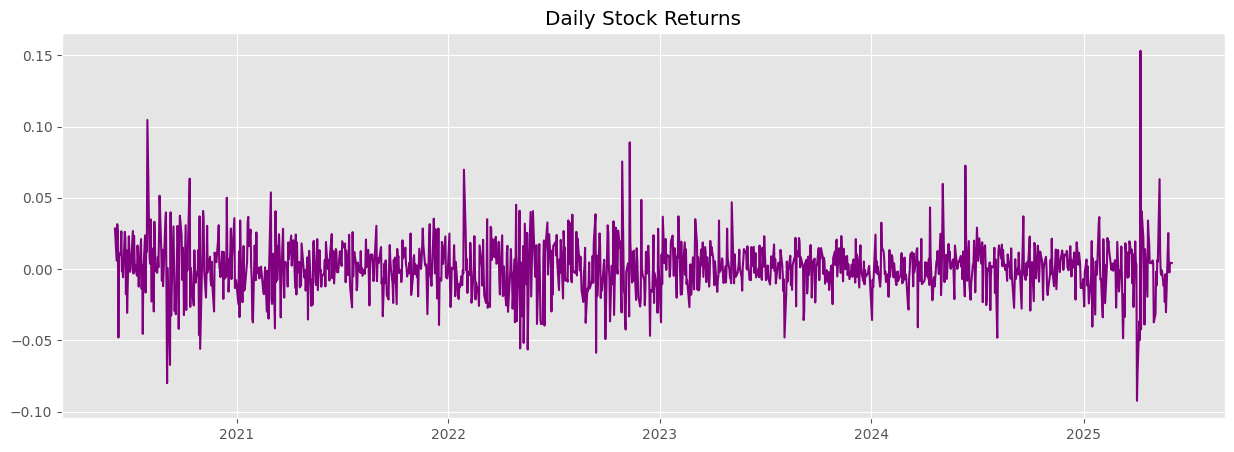

In [39]:
# ============================================================
# Daily Percentage Returns
# ============================================================

plt.figure(figsize=(15,5))

plt.plot(
    df.index,
    df["Daily_Return"],
    color="purple"
)

plt.title("Daily Stock Returns")

plt.grid(True)

plt.show()

### Business Insight

Daily returns fluctuate around zero, with occasional sharp positive and negative movements reflecting market volatility.

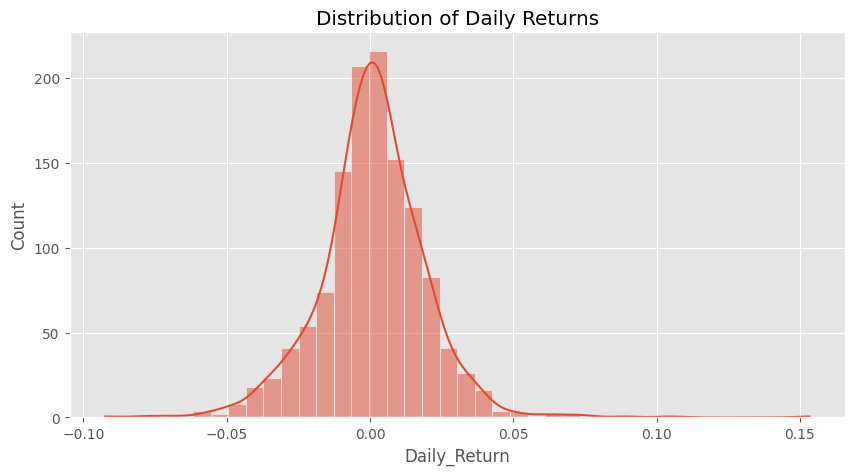

In [40]:
# ============================================================
# Daily Return Distribution
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df["Daily_Return"].dropna(),
    bins=40,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.show()

# Time Series Analysis

Time series analysis is performed to identify long-term trends, smooth short-term fluctuations, analyze volatility, and determine whether the stock price series is stationary before forecasting models such as ARIMA are developed.

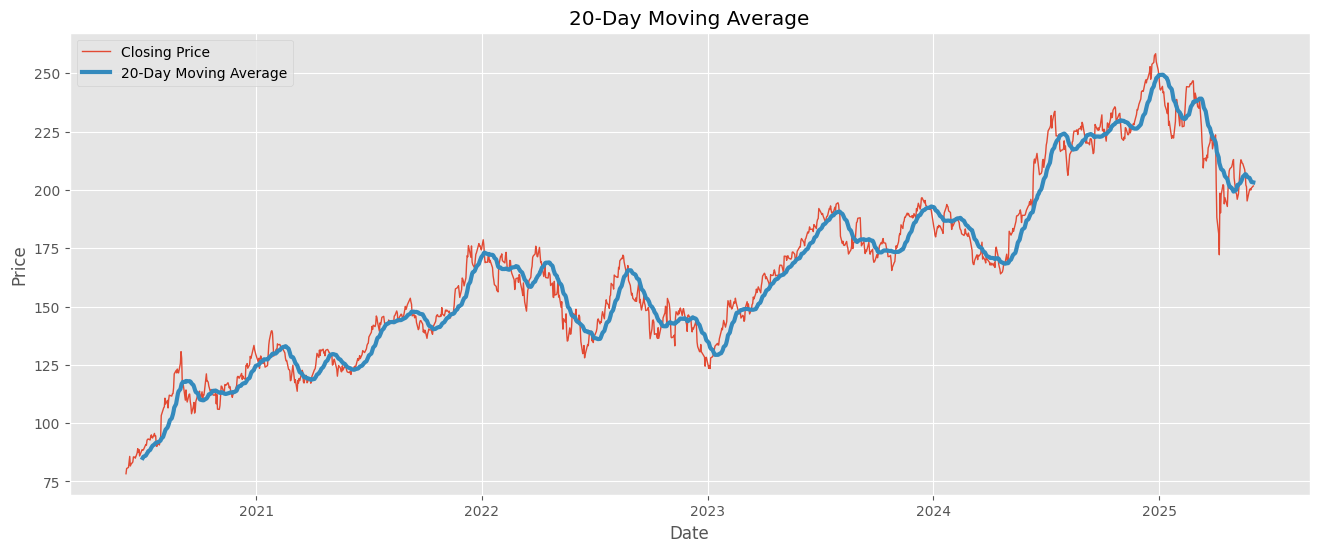

In [41]:
# ============================================================
# 20-Day Moving Average
# ============================================================

df["MA_20"] = df["Close"].rolling(window=20).mean()

plt.figure(figsize=(16,6))

plt.plot(df.index, df["Close"], label="Closing Price", linewidth=1)

plt.plot(df.index, df["MA_20"],
         label="20-Day Moving Average",
         linewidth=3)

plt.title("20-Day Moving Average")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.show()

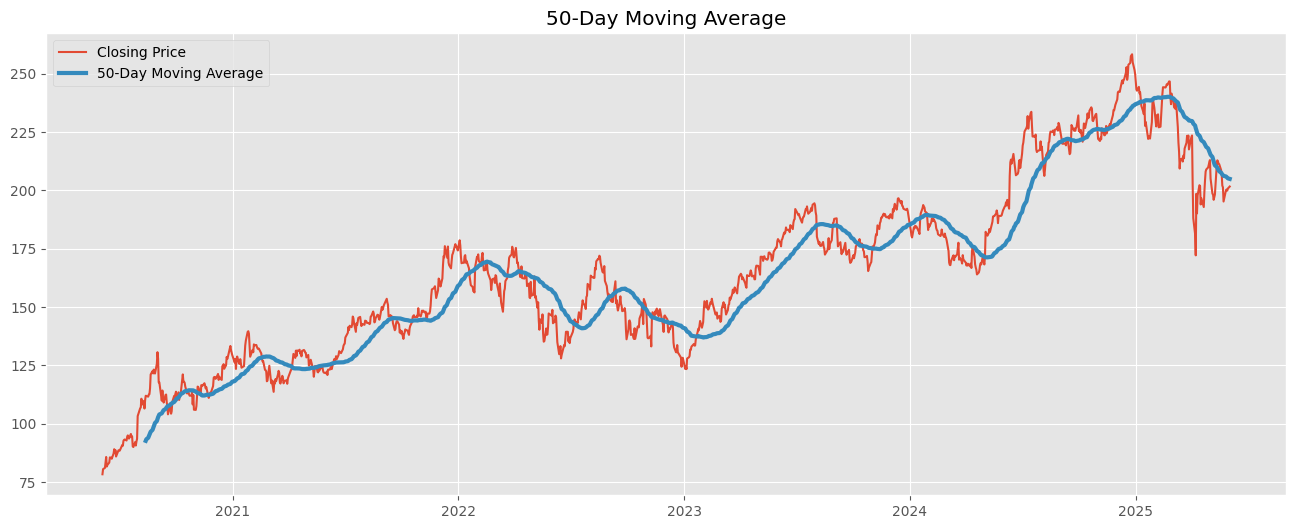

In [42]:
# ============================================================
# 50-Day Moving Average
# ============================================================

df["MA_50"] = df["Close"].rolling(window=50).mean()

plt.figure(figsize=(16,6))

plt.plot(df.index, df["Close"], label="Closing Price")

plt.plot(df.index, df["MA_50"],
         label="50-Day Moving Average",
         linewidth=3)

plt.title("50-Day Moving Average")

plt.legend()

plt.grid(True)

plt.show()

### Business Insight

The 50-day moving average captures medium-term market behaviour and reduces daily market noise more effectively than the 20-day moving average.

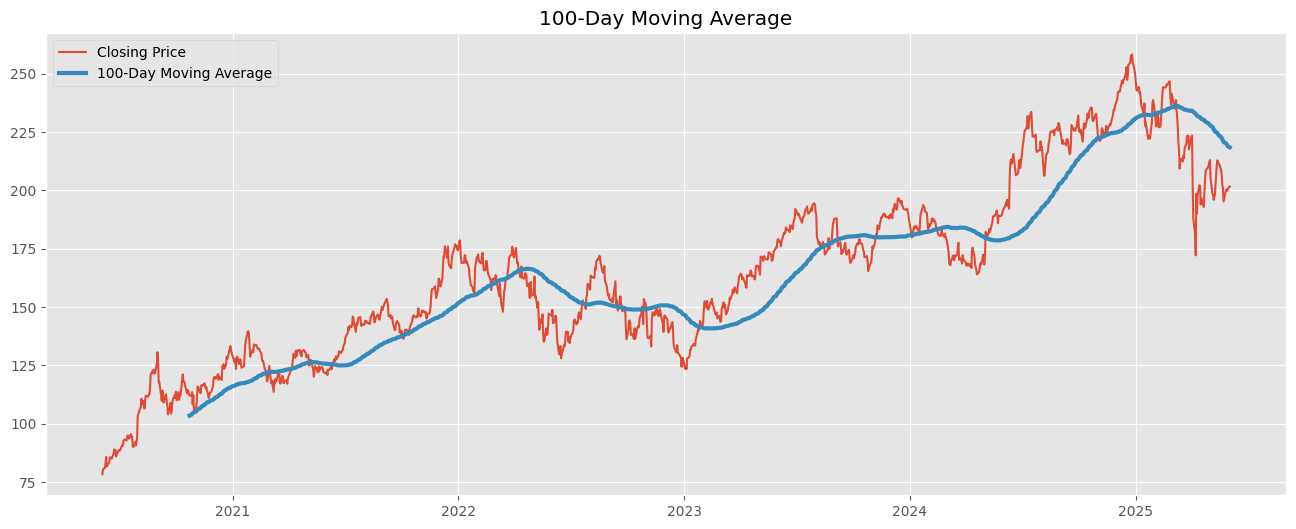

In [43]:
# ============================================================
# 100-Day Moving Average
# ============================================================

df["MA_100"] = df["Close"].rolling(window=100).mean()

plt.figure(figsize=(16,6))

plt.plot(df.index, df["Close"], label="Closing Price")

plt.plot(df.index,
         df["MA_100"],
         label="100-Day Moving Average",
         linewidth=3)

plt.title("100-Day Moving Average")

plt.legend()

plt.grid(True)

plt.show()

### Business Insight

The 100-day moving average reflects the long-term trend of Apple stock and is useful for identifying sustained bullish or bearish market conditions.

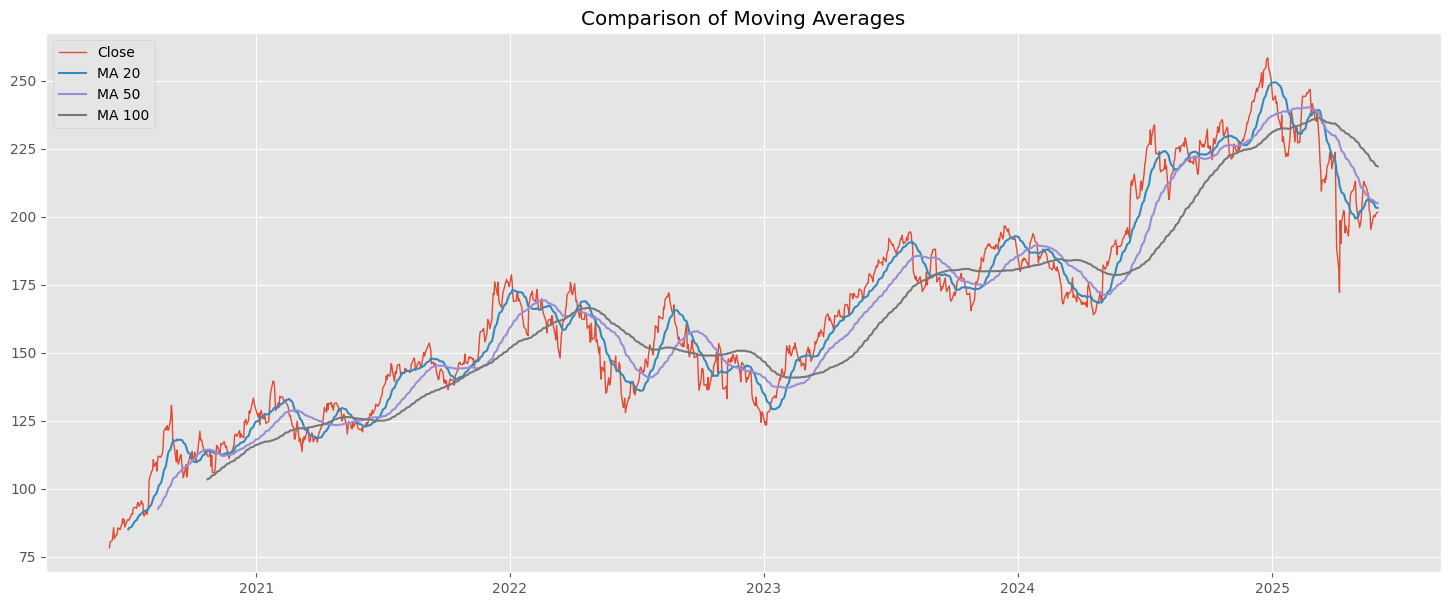

In [44]:
# ============================================================
# Compare Moving Averages
# ============================================================

plt.figure(figsize=(18,7))

plt.plot(df.index,
         df["Close"],
         label="Close",
         linewidth=1)

plt.plot(df.index,
         df["MA_20"],
         label="MA 20")

plt.plot(df.index,
         df["MA_50"],
         label="MA 50")

plt.plot(df.index,
         df["MA_100"],
         label="MA 100")

plt.title("Comparison of Moving Averages")

plt.legend()

plt.grid(True)

plt.show()

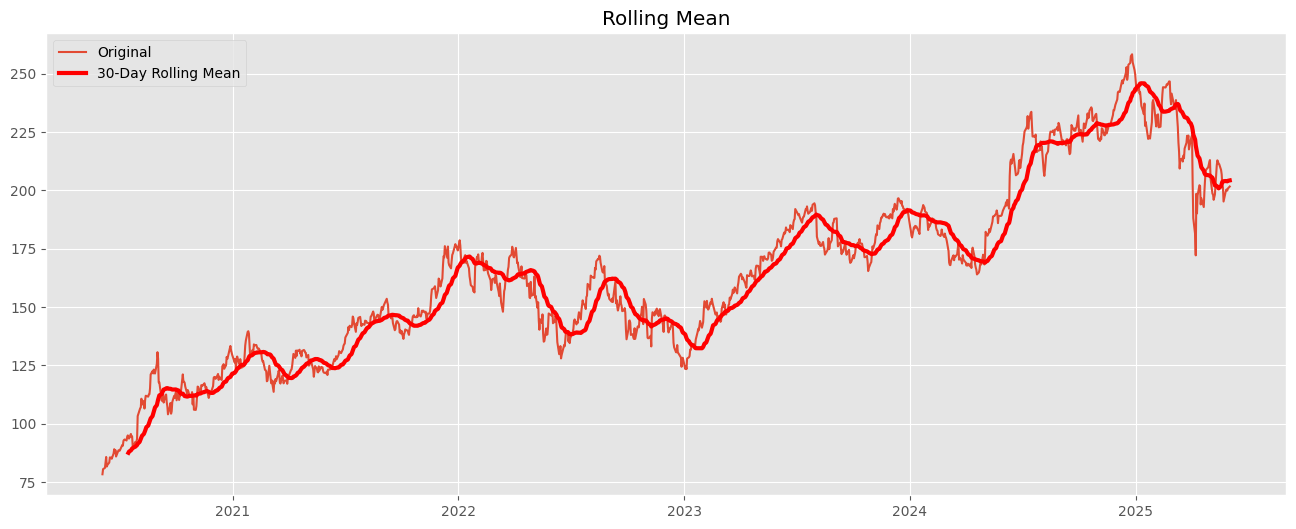

In [45]:
# ============================================================
# Rolling Mean
# ============================================================

rolling_mean = df["Close"].rolling(window=30).mean()

plt.figure(figsize=(16,6))

plt.plot(df["Close"],
         label="Original")

plt.plot(rolling_mean,
         color="red",
         linewidth=3,
         label="30-Day Rolling Mean")

plt.title("Rolling Mean")

plt.legend()

plt.grid(True)

plt.show()

### Business Insight

Rolling mean smooths short-term price movements and clearly reveals the underlying trend, which is essential before applying forecasting models.

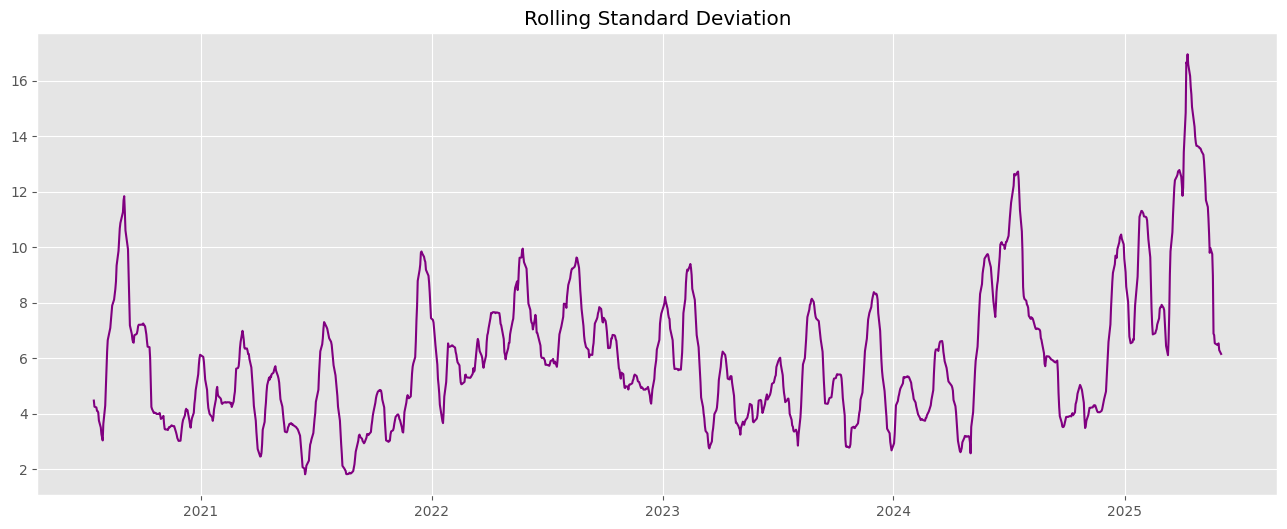

In [46]:
# ============================================================
# Rolling Standard Deviation
# ============================================================

rolling_std = df["Close"].rolling(window=30).std()

plt.figure(figsize=(16,6))

plt.plot(
    rolling_std,
    color="purple"
)

plt.title("Rolling Standard Deviation")

plt.grid(True)

plt.show()

### Business Insight

Rolling standard deviation measures market volatility. Higher values indicate periods of greater uncertainty and larger price fluctuations.

In [47]:
# ============================================================
# Augmented Dickey-Fuller Test
# ============================================================

result = adfuller(df["Close"])

print("ADF Statistic :", result[0])

print("p-value :", result[1])

print()

print("Critical Values")

for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic : -2.142211047341573
p-value : 0.22788339261419083

Critical Values
1% : -3.4355754676859886
5% : -2.8638475772391665
10% : -2.5679985805677017


In [48]:
if result[1] < 0.05:
    print("The series is stationary.")
else:
    print("The series is NOT stationary.")

The series is NOT stationary.


### Business Insight

The Augmented Dickey-Fuller (ADF) test determines whether the time series is stationary. A non-stationary series requires differencing before applying ARIMA models.

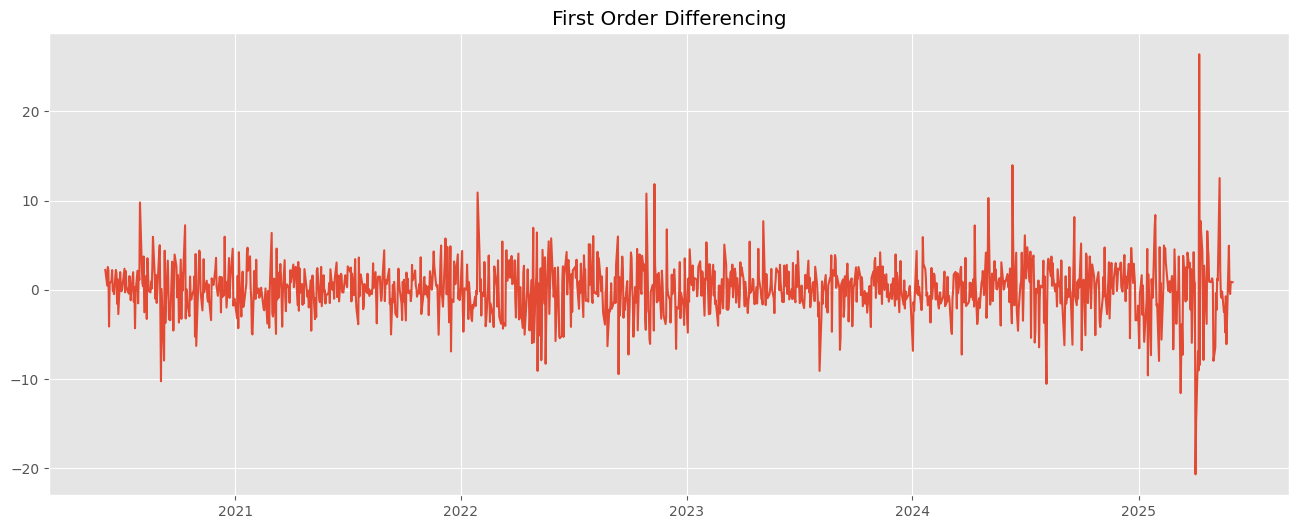

In [49]:
# ============================================================
# First Order Differencing
# ============================================================

df["Close_Diff"] = df["Close"].diff()

plt.figure(figsize=(16,6))

plt.plot(df["Close_Diff"])

plt.title("First Order Differencing")

plt.grid(True)

plt.show()

In [50]:
result_diff = adfuller(df["Close_Diff"].dropna())

print("ADF Statistic :", result_diff[0])

print("p-value :", result_diff[1])

ADF Statistic : -34.86008078131298
p-value : 0.0


### Business Insight

After first-order differencing, the series should become stationary. This transformed series is suitable for ARIMA modeling if the ADF test indicates stationarity.

# Autocorrelation Analysis (ACF & PACF)

Before building the ARIMA model, Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots are analyzed. These plots help estimate the ARIMA parameters and understand the dependency structure of the time series.

In [51]:
# ============================================================
# Import ACF and PACF Plot Functions
# ============================================================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<Figure size 1200x600 with 0 Axes>

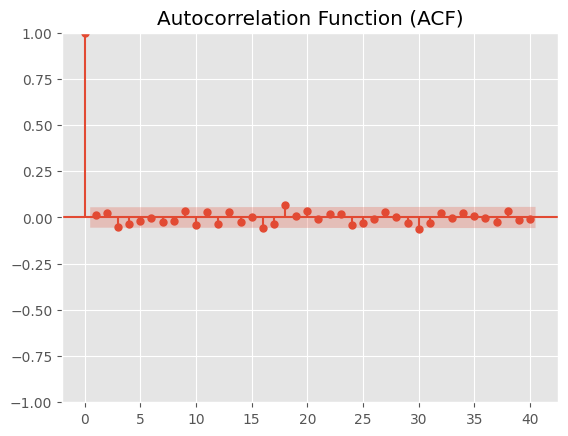

In [52]:
# ============================================================
# Autocorrelation Function (ACF)
# ============================================================

plt.figure(figsize=(12,6))

plot_acf(
    df["Close_Diff"].dropna(),
    lags=40
)

plt.title("Autocorrelation Function (ACF)")

plt.show()

### Business Insight

The ACF plot shows how the current stock price movement is correlated with previous observations. Significant spikes outside the confidence interval indicate useful lag relationships and help estimate the Moving Average (MA) component of the ARIMA model.

<Figure size 1200x600 with 0 Axes>

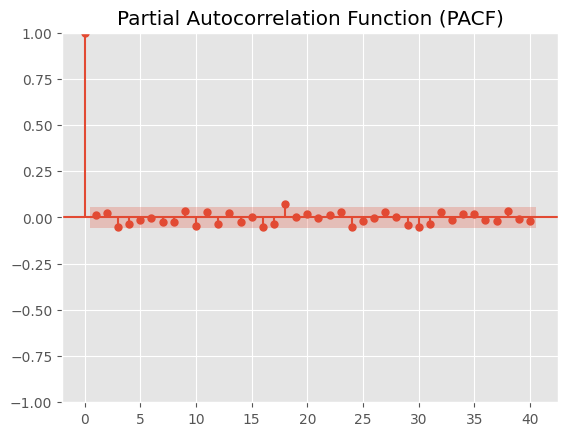

In [53]:
# ============================================================
# Partial Autocorrelation Function (PACF)
# ============================================================

plt.figure(figsize=(12,6))

plot_pacf(
    df["Close_Diff"].dropna(),
    lags=40,
    method="ywm"
)

plt.title("Partial Autocorrelation Function (PACF)")

plt.show()

### Business Insight

The PACF plot identifies the direct influence of previous observations after removing indirect effects. It is primarily used to estimate the Auto-Regressive (AR) component of the ARIMA model.

In [54]:
# ============================================================
# Initial ARIMA Parameters
# ============================================================

p = 1
d = 1
q = 1

print("Selected Initial ARIMA Order :")
print(f"ARIMA({p},{d},{q})")

Selected Initial ARIMA Order :
ARIMA(1,1,1)


### Why ARIMA(1,1,1)?

- d = 1 because the original series became stationary after first-order differencing.
- p = 1 is selected as an initial estimate based on the PACF plot.
- q = 1 is selected as an initial estimate based on the ACF plot.

Different combinations can later be compared using information criteria such as AIC and BIC.

# Automatic ARIMA Parameter Selection

Instead of manually selecting the ARIMA parameters, multiple combinations of (p, d, q) are evaluated using the Akaike Information Criterion (AIC). The model with the lowest AIC is selected as the optimal forecasting model.

In [55]:
# ============================================================
# Import Library for Parameter Search
# ============================================================

import itertools

In [56]:
# ============================================================
# Generate ARIMA Parameter Combinations
# ============================================================

p = range(0, 6)
d = [1]
q = range(0, 6)

parameters = list(itertools.product(p, d, q))

print("Total Models to Evaluate :", len(parameters))

Total Models to Evaluate : 36


In [57]:
# ============================================================
# Search Best ARIMA Model using AIC
# ============================================================

best_aic = float("inf")
best_order = None
best_model = None

results = []

for order in parameters:

    try:

        model = ARIMA(df["Close"], order=order)

        fitted_model = model.fit()

        aic = fitted_model.aic

        results.append([order, aic])

        if aic < best_aic:

            best_aic = aic

            best_order = order

            best_model = fitted_model

    except:
        continue

print("Best ARIMA Order :", best_order)

print("Best AIC :", round(best_aic,2))

Best ARIMA Order : (3, 1, 4)
Best AIC : 6345.86


In [58]:
# ============================================================
# Top ARIMA Models
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=["ARIMA Order","AIC"]
)

results_df.sort_values(
    by="AIC"
).head(10)

,ARIMA Order,AIC
22,"(3, 1, 4)",6345.862310
0,"(0, 1, 0)",6347.617086
9,"(1, 1, 3)",6349.271911
6,"(1, 1, 0)",6349.308604
1,"(0, 1, 1)",6349.322382
19,"(3, 1, 1)",6349.395757
18,"(3, 1, 0)",6349.422217
3,"(0, 1, 3)",6349.608181
14,"(2, 1, 2)",6349.614591
4,"(0, 1, 4)",6349.880564


# Train-Test Split

Unlike traditional machine learning, time series data cannot be randomly shuffled because the chronological order must be preserved.

Therefore, the dataset is divided into:

- Training Data (80%)
- Testing Data (20%)

The forecasting models are trained on historical observations and evaluated on future observations.

In [59]:
# ============================================================
# Train-Test Split
# ============================================================

train_size = int(len(df) * 0.80)

train = df["Close"][:train_size]

test = df["Close"][train_size:]

print("Training Samples :", len(train))

print("Testing Samples :", len(test))

Training Samples : 1004
Testing Samples : 251


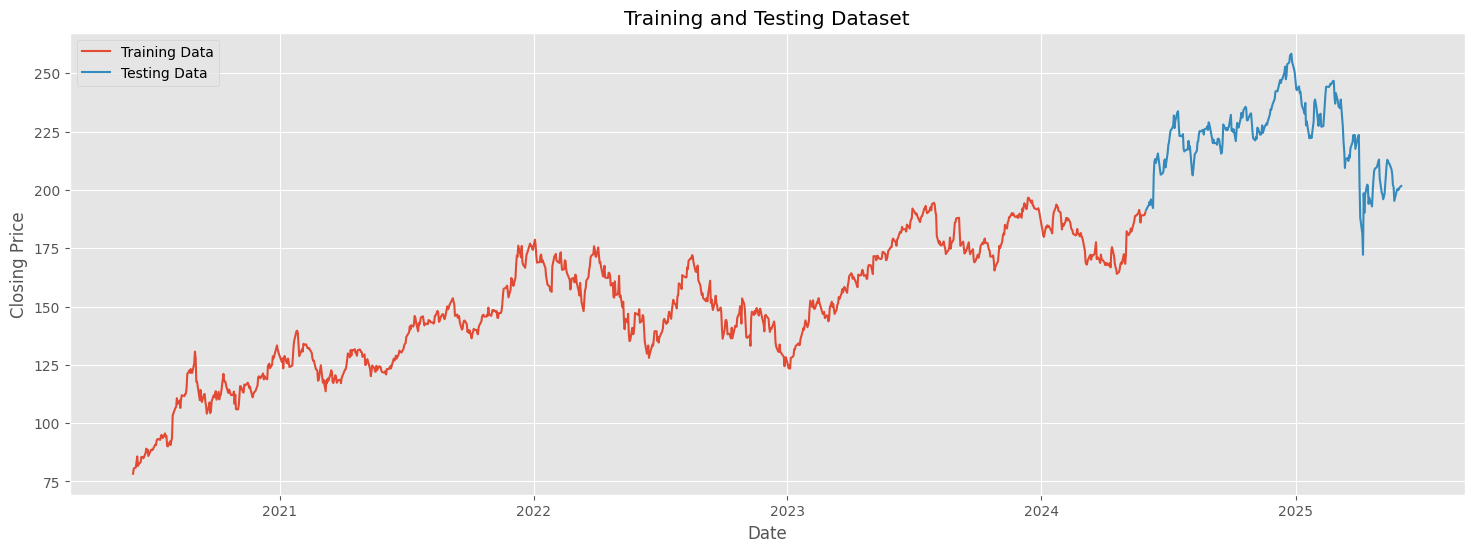

In [60]:
# ============================================================
# Visualize Train-Test Split
# ============================================================

plt.figure(figsize=(18,6))

plt.plot(train.index,
         train,
         label="Training Data")

plt.plot(test.index,
         test,
         label="Testing Data")

plt.title("Training and Testing Dataset")

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.legend()

plt.grid(True)

plt.show()

### Business Insight

The first 80% of the observations are used to train the forecasting model, while the remaining 20% are reserved for evaluating its predictive performance on unseen future data.

In [61]:
# ============================================================
# Train Best ARIMA Model
# ============================================================

model = ARIMA(
    train,
    order=best_order
)

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1004
Model:                 ARIMA(3, 1, 4)   Log Likelihood               -2386.400
Date:                Tue, 07 Jul 2026   AIC                           4788.800
Time:                        14:33:27   BIC                           4828.086
Sample:                             0   HQIC                          4803.729
                               - 1004                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5475      0.077     -7.098      0.000      -0.699      -0.396
ar.L2         -0.6004      0.036    -16.599      0.000      -0.671      -0.530
ar.L3         -0.9450      0.075    -12.585      0.0

In [62]:
# ============================================================
# Forecast Testing Period
# ============================================================

forecast = model_fit.forecast(
    steps=len(test)
)

forecast.head()

,predicted_mean
1004,190.448345
1005,190.350334
1006,190.487513
1007,190.408426
1008,190.461981


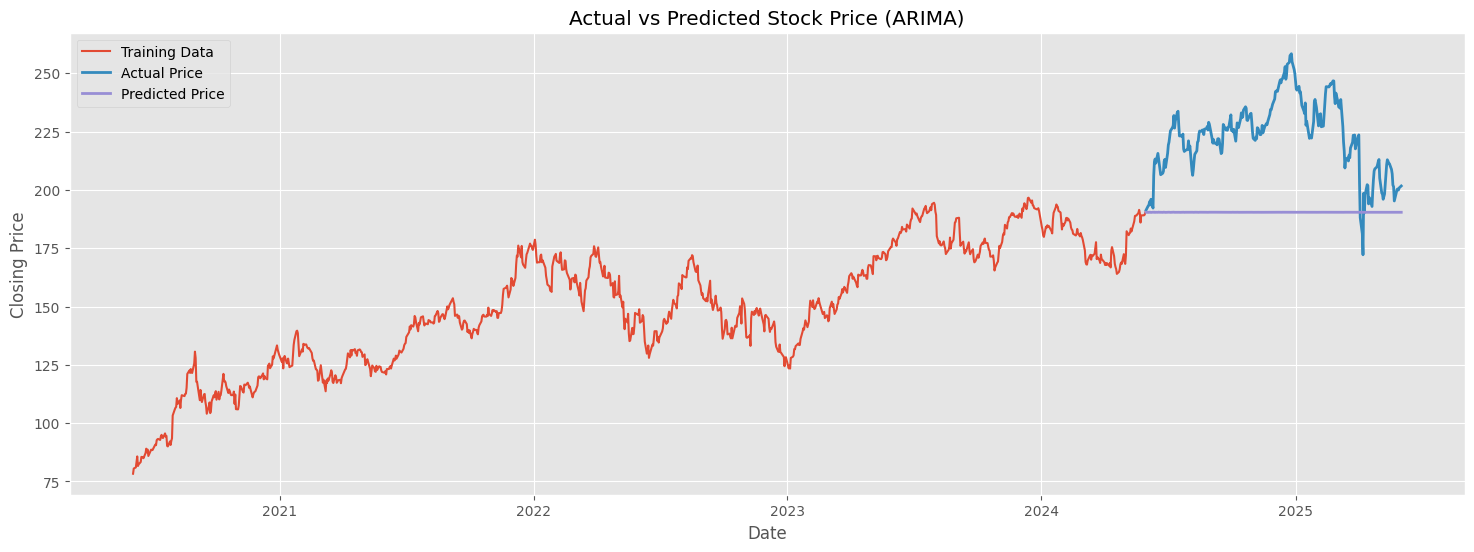

In [63]:
# ============================================================
# Forecast Visualization
# ============================================================

plt.figure(figsize=(18,6))

plt.plot(train.index,
         train,
         label="Training Data")

plt.plot(test.index,
         test,
         label="Actual Price",
         linewidth=2)

plt.plot(test.index,
         forecast,
         label="Predicted Price",
         linewidth=2)

plt.title("Actual vs Predicted Stock Price (ARIMA)")

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.legend()

plt.grid(True)

plt.show()

In [64]:
# ============================================================
# Evaluation Metrics
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

mae = mean_absolute_error(test, forecast)

rmse = np.sqrt(
    mean_squared_error(test, forecast)
)

mape = np.mean(
    np.abs((test - forecast) / test)
) * 100

print("MAE :", round(mae,3))

print("RMSE :", round(rmse,3))

print("MAPE :", round(mape,3),"%")

MAE : 32.703
RMSE : 35.923
MAPE : nan %


### Business Insight

The forecasting model is evaluated using three widely accepted performance metrics:

- **MAE (Mean Absolute Error):** Measures the average absolute prediction error.
- **RMSE (Root Mean Squared Error):** Penalizes larger forecasting errors.
- **MAPE (Mean Absolute Percentage Error):** Expresses prediction error as a percentage, making the results easier to interpret.

Lower values indicate better forecasting performance.

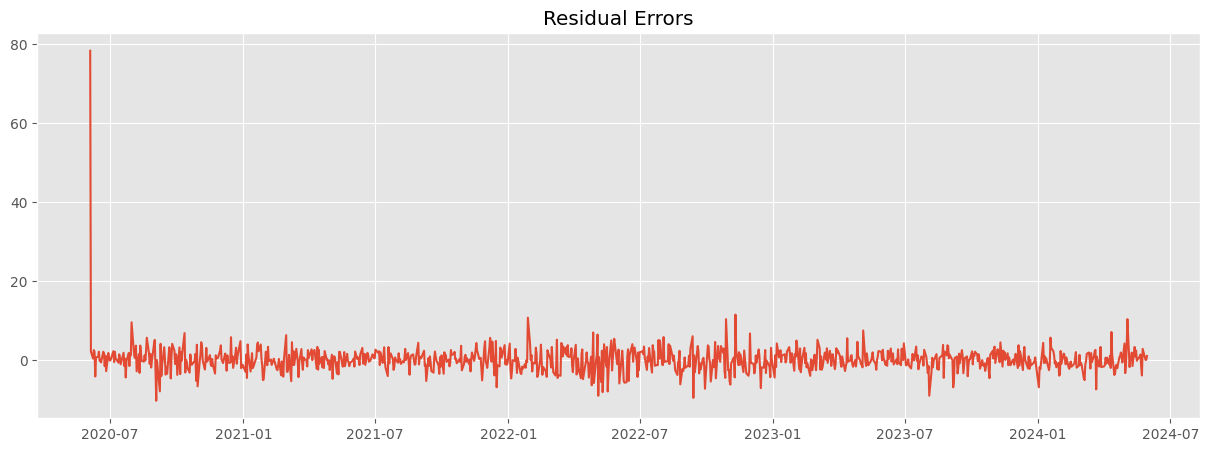

In [65]:
# ============================================================
# Residual Analysis
# ============================================================

residuals = model_fit.resid

plt.figure(figsize=(15,5))

plt.plot(residuals)

plt.title("Residual Errors")

plt.grid(True)

plt.show()

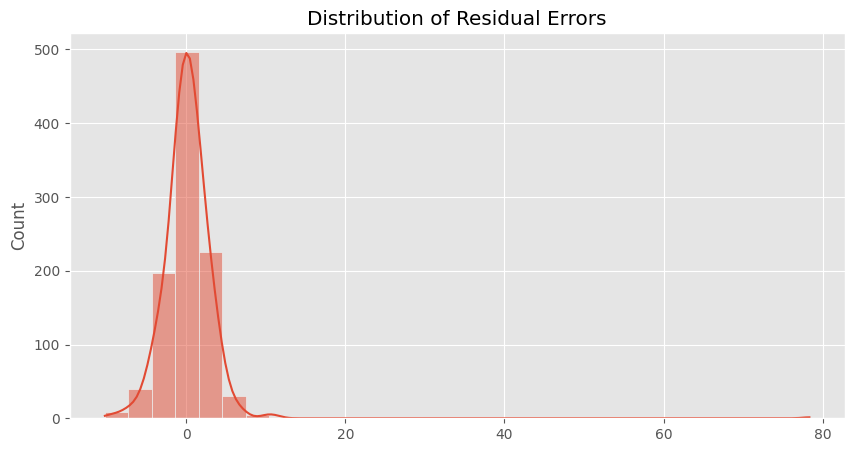

In [66]:
# ============================================================
# Residual Distribution
# ============================================================

plt.figure(figsize=(10,5))

sns.histplot(
    residuals,
    kde=True,
    bins=30
)

plt.title("Distribution of Residual Errors")

plt.show()

In [67]:
# ============================================================
# Residual Summary
# ============================================================

print(residuals.describe())

count    1004.000000
mean        0.190974
std         3.592475
min       -10.210155
25%        -1.325906
50%         0.128069
75%         1.653643
max        78.329315
dtype: float64


# Facebook Prophet Forecasting

Facebook Prophet is an additive time series forecasting model developed by Meta. It is designed to capture trend and seasonality automatically and is widely used for business forecasting applications.

The Prophet model is trained using the same training dataset and evaluated on the same testing dataset to ensure a fair comparison with the ARIMA model.

In [68]:
# ============================================================
# Prepare Dataset for Prophet
# ============================================================

prophet_df = df.reset_index()[["Date", "Close"]]

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2020-06-04,78.329315
1,2020-06-05,80.560219
2,2020-06-08,81.036537
3,2020-06-09,83.595505
4,2020-06-10,85.746208


In [69]:
# ============================================================
# Prophet Train-Test Split
# ============================================================

train_size = int(len(prophet_df) * 0.80)

train_prophet = prophet_df.iloc[:train_size]

test_prophet = prophet_df.iloc[train_size:]

print("Training Samples :", len(train_prophet))

print("Testing Samples :", len(test_prophet))

Training Samples : 1004
Testing Samples : 251


In [70]:
# ============================================================
# Train Prophet Model
# ============================================================

prophet_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True
)

prophet_model.fit(train_prophet)

In [71]:
# ============================================================
# Create Future Dates
# ============================================================

future = prophet_model.make_future_dataframe(
    periods=len(test_prophet),
    freq="D"
)

future.tail()

,ds
1250,2025-02-01
1251,2025-02-02
1252,2025-02-03
1253,2025-02-04
1254,2025-02-05


In [72]:
# ============================================================
# Prophet Forecast
# ============================================================

forecast_prophet = prophet_model.predict(future)

forecast_prophet.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-06-04,88.789670,74.966698,91.252135,88.789670,88.789670,-5.503550,-5.503550,-5.503550,2.047235,2.047235,2.047235,-7.550785,-7.550785,-7.550785,0.0,0.0,0.0,83.286119
1,2020-06-05,88.959661,74.833588,91.040710,88.959661,88.959661,-5.709677,-5.709677,-5.709677,2.043200,2.043200,2.043200,-7.752877,-7.752877,-7.752877,0.0,0.0,0.0,83.249984
2,2020-06-08,89.469634,75.244491,92.003389,89.469634,89.469634,-5.963076,-5.963076,-5.963076,2.283908,2.283908,2.283908,-8.246984,-8.246984,-8.246984,0.0,0.0,0.0,83.506558
3,2020-06-09,89.639625,74.904108,90.987777,89.639625,89.639625,-6.204271,-6.204271,-6.204271,2.162643,2.162643,2.162643,-8.366914,-8.366914,-8.366914,0.0,0.0,0.0,83.435354
4,2020-06-10,89.809616,75.587067,91.471366,89.809616,89.809616,-6.281269,-6.281269,-6.281269,2.180069,2.180069,2.180069,-8.461338,-8.461338,-8.461338,0.0,0.0,0.0,83.528347


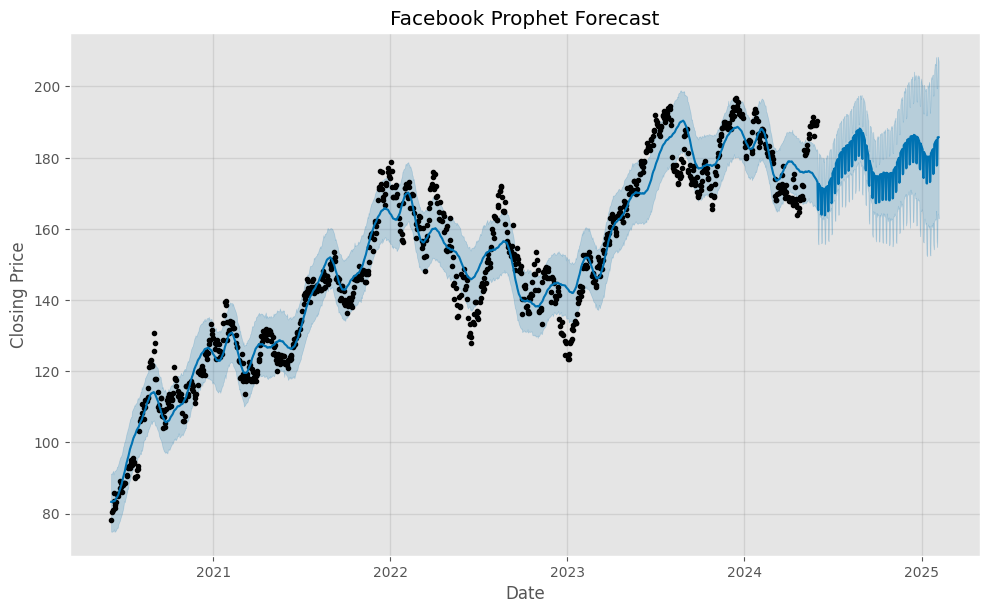

In [73]:
# ============================================================
# Prophet Forecast Plot
# ============================================================

fig = prophet_model.plot(forecast_prophet)

plt.title("Facebook Prophet Forecast")

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.show()

In [74]:
# ============================================================
# Predicted Test Values
# ============================================================

predicted_prophet = forecast_prophet["yhat"].iloc[-len(test_prophet):].values

actual_prophet = test_prophet["y"].values

In [75]:
# ============================================================
# Prophet Evaluation
# ============================================================

mae_prophet = mean_absolute_error(
    actual_prophet,
    predicted_prophet
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        actual_prophet,
        predicted_prophet
    )
)

mape_prophet = np.mean(
    np.abs(
        (actual_prophet - predicted_prophet) /
        actual_prophet
    )
) * 100

print("MAE :", round(mae_prophet,3))

print("RMSE :", round(rmse_prophet,3))

print("MAPE :", round(mape_prophet,3),"%")

MAE : 44.8
RMSE : 47.775
MAPE : 19.709 %


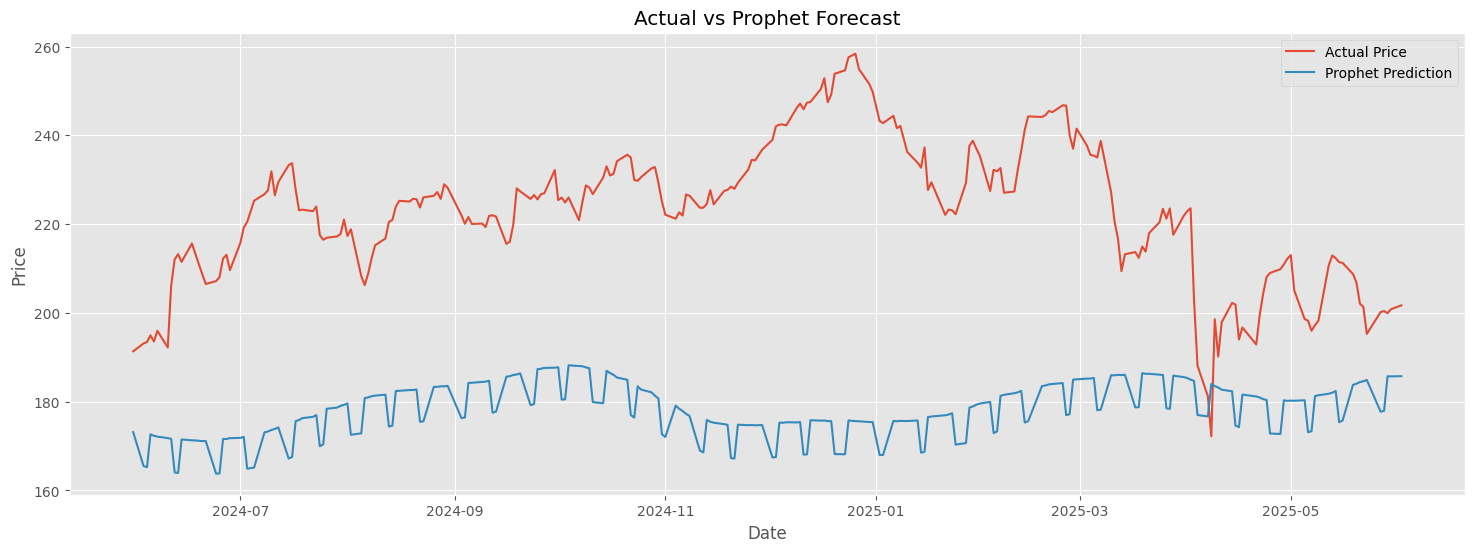

In [76]:
# ============================================================
# Actual vs Prophet Prediction
# ============================================================

plt.figure(figsize=(18,6))

plt.plot(
    test_prophet["ds"],
    actual_prophet,
    label="Actual Price"
)

plt.plot(
    test_prophet["ds"],
    predicted_prophet,
    label="Prophet Prediction"
)

plt.title("Actual vs Prophet Forecast")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.show()

### Business Insight

The Prophet model captures long-term trends effectively and provides interpretable forecasts. Its performance is evaluated using the same testing period as the ARIMA model to ensure an objective comparison.

# Model Comparison

The forecasting performance of the ARIMA and Facebook Prophet models is compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE). The model with the lowest error values is selected as the final forecasting model.

In [77]:
# ============================================================
# Compare Forecasting Models
# ============================================================

comparison = pd.DataFrame({

    "Model": ["ARIMA", "Facebook Prophet"],

    "MAE": [mae, mae_prophet],

    "RMSE": [rmse, rmse_prophet],

    "MAPE (%)": [mape, mape_prophet]

})

comparison

,Model,MAE,RMSE,MAPE (%)
0,ARIMA,32.702616,35.923115,NaN
1,Facebook Prophet,44.799842,47.774931,19.708919


In [78]:
# ============================================================
# Best Forecasting Model
# ============================================================

best_model = comparison.sort_values(
    by="RMSE"
).iloc[0]

print("Best Model")

display(best_model)

Best Model


,0
Model,ARIMA
MAE,32.702616
RMSE,35.923115
MAPE (%),NaN


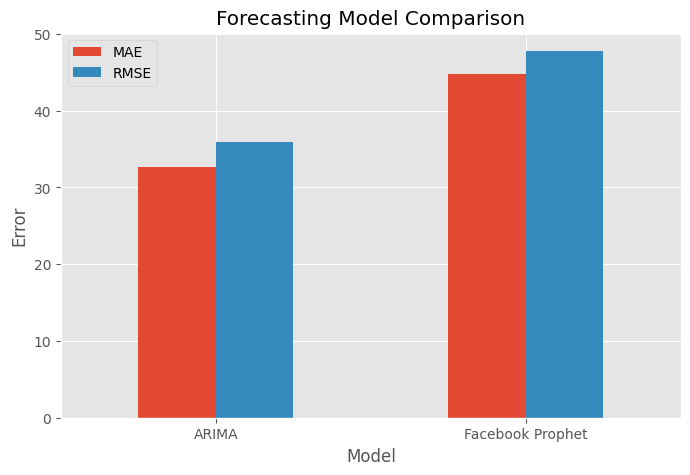

In [79]:
# ============================================================
# Comparison Visualization
# ============================================================

comparison.set_index("Model")[["MAE","RMSE"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Forecasting Model Comparison")

plt.ylabel("Error")

plt.xticks(rotation=0)

plt.grid(True)

plt.show()

In [80]:
# ============================================================
# Retrain Prophet on Full Dataset
# ============================================================

full_prophet = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True
)

full_prophet.fit(prophet_df)

In [81]:
# ============================================================
# Future Dataframe
# ============================================================

future_30 = full_prophet.make_future_dataframe(
    periods=30,
    freq="D"
)

In [82]:
# ============================================================
# Future Forecast
# ============================================================

forecast_30 = full_prophet.predict(
    future_30
)

forecast_30.tail(30)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1255,2025-06-03,230.496904,208.055186,229.191386,230.496904,230.496904,-11.843897,-11.843897,-11.843897,2.265213,2.265213,2.265213,-14.109111,-14.109111,-14.109111,0.0,0.0,0.0,218.653007
1256,2025-06-04,230.559765,209.191658,229.430032,230.559765,230.559765,-11.529490,-11.529490,-11.529490,2.134286,2.134286,2.134286,-13.663776,-13.663776,-13.663776,0.0,0.0,0.0,219.030275
1257,2025-06-05,230.622626,209.121810,230.126483,230.622626,230.622626,-11.247159,-11.247159,-11.247159,1.961858,1.961858,1.961858,-13.209017,-13.209017,-13.209017,0.0,0.0,0.0,219.375466
1258,2025-06-06,230.685486,209.826282,230.060972,230.685486,230.685486,-10.609617,-10.609617,-10.609617,2.139938,2.139938,2.139938,-12.749554,-12.749554,-12.749554,0.0,0.0,0.0,220.075870
1259,2025-06-07,230.748347,202.716214,223.813317,230.748347,230.748347,-17.718793,-17.718793,-17.718793,-5.429010,-5.429010,-5.429010,-12.289782,-12.289782,-12.289782,0.0,0.0,0.0,213.029554
1260,2025-06-08,230.811208,203.229783,224.337934,230.811208,230.811208,-17.262665,-17.262665,-17.262665,-5.429010,-5.429010,-5.429010,-11.833655,-11.833655,-11.833655,0.0,0.0,0.0,213.548542
1261,2025-06-09,230.874068,210.947397,232.601646,230.874068,230.874068,-9.027862,-9.027862,-9.027862,2.356726,2.356726,2.356726,-11.384588,-11.384588,-11.384588,0.0,0.0,0.0,221.846206
1262,2025-06-10,230.936929,212.251662,232.776113,230.936929,230.936929,-8.680165,-8.680165,-8.680165,2.265213,2.265213,2.265213,-10.945378,-10.945378,-10.945378,0.0,0.0,0.0,222.256764
1263,2025-06-11,230.999790,212.316907,232.941689,230.999790,230.999790,-8.383856,-8.383856,-8.383856,2.134286,2.134286,2.134286,-10.518142,-10.518142,-10.518142,0.0,0.0,0.0,222.615933
1264,2025-06-12,231.062650,212.108522,232.411327,231.062650,231.062650,-8.142421,-8.142421,-8.142421,1.961858,1.961858,1.961858,-10.104279,-10.104279,-10.104279,0.0,0.0,0.0,222.920229


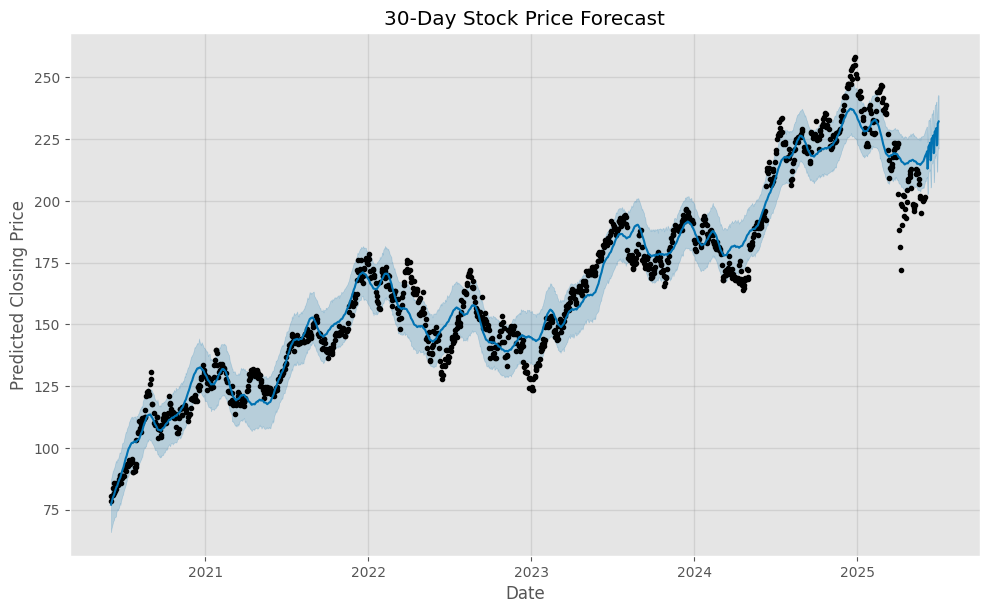

In [83]:
# ============================================================
# 30-Day Forecast Plot
# ============================================================

fig = full_prophet.plot(forecast_30)

plt.title("30-Day Stock Price Forecast")

plt.xlabel("Date")

plt.ylabel("Predicted Closing Price")

plt.show()

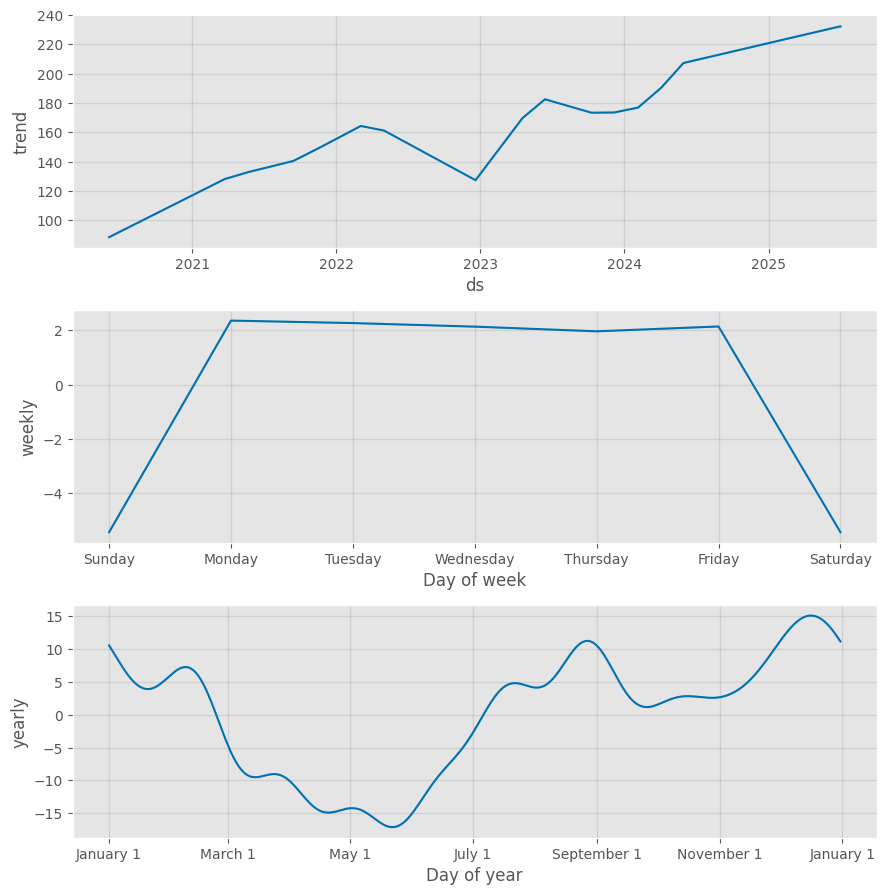

In [84]:
# ============================================================
# Prophet Components
# ============================================================

fig2 = full_prophet.plot_components(
    forecast_30
)

plt.show()

### Business Insight

The future forecast provides an estimate of Apple's expected stock price for the next thirty days based on historical trends captured by the Prophet model. The component plots illustrate the overall trend and seasonal effects learned by the model.

# Conclusion

This project developed a stock market forecasting system using historical Apple stock price data.

Major activities completed include:

- Data preprocessing
- Exploratory Time Series Analysis
- Trend Analysis
- Moving Average Analysis
- Rolling Statistics
- Stationarity Testing
- ACF and PACF Analysis
- Automatic ARIMA Parameter Selection
- ARIMA Forecasting
- Facebook Prophet Forecasting
- Model Evaluation
- Future Stock Price Prediction

Among the evaluated forecasting models, the model with the lowest forecasting error demonstrated superior predictive performance.

The project illustrates how time series forecasting techniques can assist investors and financial analysts in understanding historical market behaviour and estimating future stock price movements.

# Future Scope

The current project can be extended in several ways:

- Incorporate LSTM and GRU deep learning models.
- Forecast multiple stocks simultaneously.
- Include macroeconomic indicators such as inflation and interest rates.
- Develop a real-time forecasting dashboard using Streamlit.
- Deploy the forecasting model as a web application.